In [3]:
# imports 
import pandas as pd
import os 
import sys
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))
from src.data_loader import load_data, load_data_from_file
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, learning_curve
from sklearn.feature_selection import RFECV


from sklearn.model_selection import (
    cross_validate,
    cross_val_score,
    KFold,
    StratifiedKFold,
)
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)
import xgboost as xgb
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.model_selection import validation_curve
from sklearn.metrics import roc_auc_score, average_precision_score
import umap
import matplotlib.pyplot as plt

In [2]:
location = '../data/raw/'
df = load_data_from_file(file_path=os.path.join(location, 'SantanderCustomerSatisfaction.csv'))

def tweak_df(df):
    df = df.copy()
    df['target'] = df['target'].astype('category')
    return df
df = tweak_df(df)


Loading dataset from file: ../data/raw/SantanderCustomerSatisfaction.csv...


In [3]:
df['target'].value_counts(normalize=True)

target
False    0.89951
True     0.10049
Name: proportion, dtype: float64

In [3]:
(
    df_train,
    df_test,
    y_train,
    y_test,
) = train_test_split(
    df.drop(columns=['target']),
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target'],
)

def run_cv(estimator, X, y, cv, verbose=3):
    return cross_validate(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring=("roc_auc", "average_precision"),
        return_estimator=True,
        return_indices=True,
        return_train_score=True,
        verbose=verbose,
    )
    
def print_test_scores(cv_results, scorings=("test_roc_auc", "test_average_precision")):
    for score in scorings:
        print(
            f"mean {score:30s} score = {cv_results[score].mean():.5f} +/- {cv_results[score].std():.5f}"
        )
        
def print_train_scores(cv_results, scorings=("train_roc_auc", "train_average_precision")):
    for score in scorings:
        print(
            f"mean {score:30s} score = {cv_results[score].mean():.5f} +/- {cv_results[score].std():.5f}"
        )

p_xgb = make_pipeline(
    xgb.XGBClassifier(   
    random_state=42,   
)
)

def _plot_validation_curve(param_name, param_range, scorings): 
    n_scoring = len(scorings)
    fig, axes = plt.subplots(1, n_scoring, figsize=(7 * n_scoring, 5), sharey=False)

    if n_scoring == 1:
        axes = [axes]  
    
    for ax, scoring in zip(axes, scorings):
        train_scores, test_scores = validation_curve(
            p_xgb,            
            X=df_train,             
            y=y_train,              
            param_name=param_name,
            param_range=param_range,
            scoring=scoring,      
            cv=3,
            verbose=3         
        )

        # mean & std
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        # plot
        ax.plot(param_range, train_mean, label="Train score", color="blue")
        ax.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
        ax.plot(param_range, test_mean, label="Validation score", color="green")
        ax.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="green")
        
        ax.set_xlabel(param_name)
        ax.set_ylabel(scoring)
        ax.set_title(f"Validation Curve: {param_name} ({scoring})")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
p_xgb.fit(df_train, y_train)
xgb_model = p_xgb.named_steps['xgbclassifier']

# Get feature importances by gain
importances = xgb_model.get_booster().get_score(importance_type='gain')

importances_df = pd.DataFrame({
    'feature': list(importances.keys()),
    'importance': list(importances.values())
}).sort_values(by='importance', ascending=False)

importances_df["importance"] = (
    importances_df["importance"] / importances_df["importance"].sum() * 100
)

# sort descending
importances_df = importances_df.sort_values(by="importance", ascending=False)

# round for readability (optional)
importances_df["importance"] = importances_df["importance"].round(2)



,feature,importance
81,var_81,1.79
139,var_139,1.51
110,var_110,1.48
12,var_12,1.39
53,var_53,1.26
174,var_174,1.20
146,var_146,1.15
6,var_6,1.09
80,var_80,1.07
76,var_76,1.05


In [11]:
print(importances_df.head(20))

     feature  importance
81    var_81        1.79
139  var_139        1.51
110  var_110        1.48
12    var_12        1.39
53    var_53        1.26
174  var_174        1.20
146  var_146        1.15
6      var_6        1.09
80    var_80        1.07
76    var_76        1.05
109  var_109        1.02
26    var_26        1.01
133  var_133        0.99
0      var_0        0.96
190  var_190        0.96
166  var_166        0.93
179  var_179        0.91
22    var_22        0.91
44    var_44        0.90
21    var_21        0.90


[CV] END xgbclassifier__max_depth=2;, score=(train=0.882, test=0.853) total time=   7.1s
[CV] END xgbclassifier__max_depth=3;, score=(train=0.911, test=0.859) total time=   8.2s
[CV] END xgbclassifier__max_depth=4;, score=(train=0.942, test=0.858) total time=  10.0s
[CV] END xgbclassifier__max_depth=5;, score=(train=0.971, test=0.857) total time=  12.5s
[CV] END xgbclassifier__max_depth=6;, score=(train=0.992, test=0.849) total time=  17.4s
[CV] END xgbclassifier__max_depth=7;, score=(train=0.999, test=0.841) total time=  20.0s
[CV] END xgbclassifier__max_depth=2;, score=(train=0.882, test=0.857) total time=   6.8s
[CV] END xgbclassifier__max_depth=3;, score=(train=0.910, test=0.862) total time=   8.8s
[CV] END xgbclassifier__max_depth=4;, score=(train=0.939, test=0.863) total time=   9.6s
[CV] END xgbclassifier__max_depth=5;, score=(train=0.970, test=0.858) total time=  12.4s
[CV] END xgbclassifier__max_depth=6;, score=(train=0.992, test=0.851) total time=  16.3s
[CV] END xgbclassifie

[Parallel(n_jobs=1)]: Done  18 out of  18 | elapsed:  3.9min finished


[CV] END xgbclassifier__max_depth=2;, score=(train=0.571, test=0.489) total time=   8.3s
[CV] END xgbclassifier__max_depth=3;, score=(train=0.661, test=0.498) total time=   9.1s
[CV] END xgbclassifier__max_depth=4;, score=(train=0.765, test=0.497) total time=  12.8s
[CV] END xgbclassifier__max_depth=5;, score=(train=0.877, test=0.493) total time=  12.3s
[CV] END xgbclassifier__max_depth=6;, score=(train=0.965, test=0.479) total time=  14.5s
[CV] END xgbclassifier__max_depth=7;, score=(train=0.997, test=0.458) total time=  18.4s
[CV] END xgbclassifier__max_depth=2;, score=(train=0.573, test=0.496) total time=   6.4s
[CV] END xgbclassifier__max_depth=3;, score=(train=0.657, test=0.504) total time=   7.5s
[CV] END xgbclassifier__max_depth=4;, score=(train=0.758, test=0.505) total time=   8.7s
[CV] END xgbclassifier__max_depth=5;, score=(train=0.874, test=0.499) total time=  12.5s
[CV] END xgbclassifier__max_depth=6;, score=(train=0.965, test=0.474) total time=  16.0s
[CV] END xgbclassifie

[Parallel(n_jobs=1)]: Done  18 out of  18 | elapsed:  3.8min finished


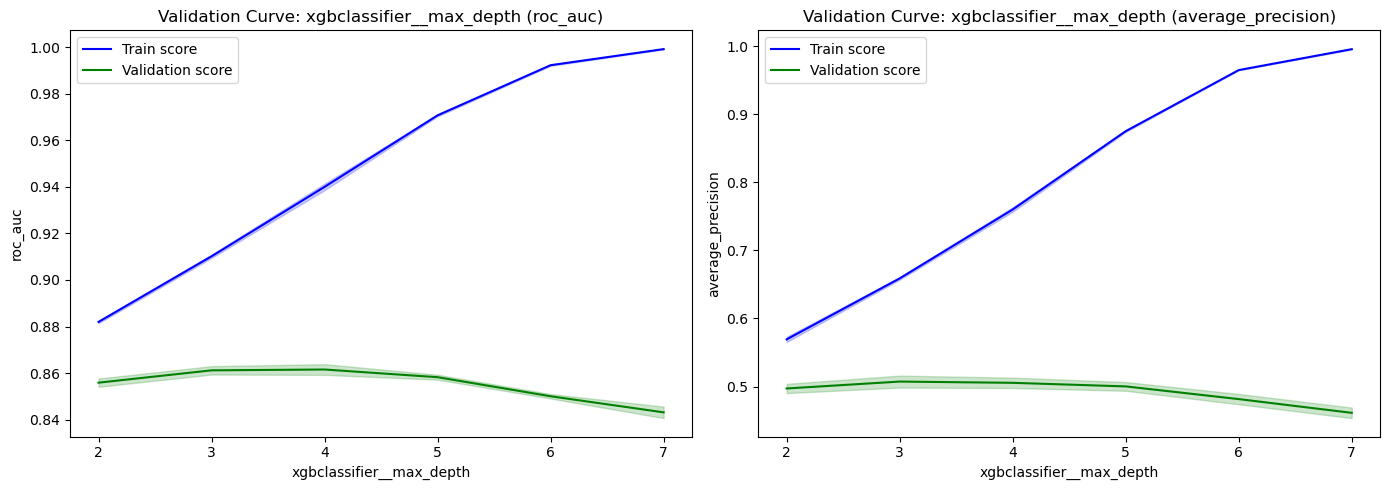

In [7]:
param_name = "xgbclassifier__max_depth"
param_range = np.arange(2, 8)

_plot_validation_curve(param_name, param_range, scorings=("roc_auc", "average_precision"))

[CV] END xgbclassifier__learning_rate=0.01;, score=(train=0.829, test=0.759) total time=  18.7s
[CV] END xgbclassifier__learning_rate=0.05;, score=(train=0.934, test=0.833) total time=  19.0s
[CV] END xgbclassifier__learning_rate=0.1;, score=(train=0.964, test=0.851) total time=  16.4s
[CV] END xgbclassifier__learning_rate=0.2;, score=(train=0.985, test=0.855) total time=  18.7s
[CV] END xgbclassifier__learning_rate=0.3;, score=(train=0.992, test=0.849) total time=  20.5s
[CV] END xgbclassifier__learning_rate=0.01;, score=(train=0.827, test=0.766) total time=  15.0s
[CV] END xgbclassifier__learning_rate=0.05;, score=(train=0.932, test=0.836) total time=  13.9s
[CV] END xgbclassifier__learning_rate=0.1;, score=(train=0.964, test=0.853) total time=  12.4s
[CV] END xgbclassifier__learning_rate=0.2;, score=(train=0.984, test=0.858) total time=  13.3s
[CV] END xgbclassifier__learning_rate=0.3;, score=(train=0.992, test=0.851) total time=  13.5s
[CV] END xgbclassifier__learning_rate=0.01;, s

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:  3.8min finished


[CV] END xgbclassifier__learning_rate=0.01;, score=(train=0.527, test=0.319) total time=  11.1s
[CV] END xgbclassifier__learning_rate=0.05;, score=(train=0.773, test=0.450) total time=  11.4s
[CV] END xgbclassifier__learning_rate=0.1;, score=(train=0.865, test=0.483) total time=  12.3s
[CV] END xgbclassifier__learning_rate=0.2;, score=(train=0.936, test=0.492) total time=  11.9s
[CV] END xgbclassifier__learning_rate=0.3;, score=(train=0.965, test=0.479) total time=  12.1s
[CV] END xgbclassifier__learning_rate=0.01;, score=(train=0.521, test=0.316) total time=  10.4s
[CV] END xgbclassifier__learning_rate=0.05;, score=(train=0.770, test=0.449) total time=  10.9s
[CV] END xgbclassifier__learning_rate=0.1;, score=(train=0.861, test=0.484) total time=  11.6s
[CV] END xgbclassifier__learning_rate=0.2;, score=(train=0.932, test=0.489) total time=  12.1s
[CV] END xgbclassifier__learning_rate=0.3;, score=(train=0.965, test=0.474) total time=  11.5s
[CV] END xgbclassifier__learning_rate=0.01;, s

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:  2.9min finished


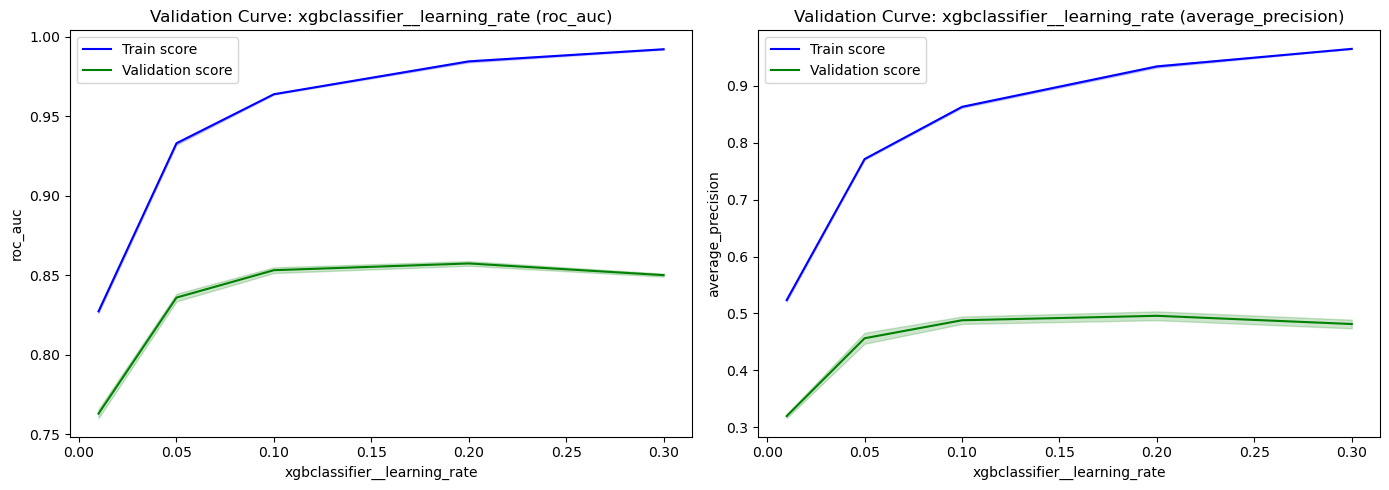

In [8]:
param_name = "xgbclassifier__learning_rate"
param_range = [0.01, 0.05, 0.1, 0.2, 0.3]

_plot_validation_curve(param_name, param_range, scorings=("roc_auc", "average_precision"))

[CV] END xgbclassifier__n_estimators=50;, score=(train=0.966, test=0.831) total time=   6.5s
[CV] END xgbclassifier__n_estimators=100;, score=(train=0.992, test=0.849) total time=  12.1s
[CV] END xgbclassifier__n_estimators=200;, score=(train=1.000, test=0.856) total time=  22.0s
[CV] END xgbclassifier__n_estimators=300;, score=(train=1.000, test=0.858) total time=  31.9s
[CV] END xgbclassifier__n_estimators=400;, score=(train=1.000, test=0.860) total time=  40.7s
[CV] END xgbclassifier__n_estimators=50;, score=(train=0.967, test=0.836) total time=   6.8s
[CV] END xgbclassifier__n_estimators=100;, score=(train=0.992, test=0.851) total time=  12.4s
[CV] END xgbclassifier__n_estimators=200;, score=(train=1.000, test=0.858) total time=  22.8s
[CV] END xgbclassifier__n_estimators=300;, score=(train=1.000, test=0.860) total time=  31.6s
[CV] END xgbclassifier__n_estimators=400;, score=(train=1.000, test=0.863) total time=  42.3s
[CV] END xgbclassifier__n_estimators=50;, score=(train=0.967, 

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:  5.8min finished


[CV] END xgbclassifier__n_estimators=50;, score=(train=0.865, test=0.436) total time=   6.4s
[CV] END xgbclassifier__n_estimators=100;, score=(train=0.965, test=0.479) total time=  12.2s
[CV] END xgbclassifier__n_estimators=200;, score=(train=0.998, test=0.500) total time=  21.7s
[CV] END xgbclassifier__n_estimators=300;, score=(train=1.000, test=0.504) total time=  31.4s
[CV] END xgbclassifier__n_estimators=400;, score=(train=1.000, test=0.510) total time=  41.1s
[CV] END xgbclassifier__n_estimators=50;, score=(train=0.866, test=0.438) total time=   6.4s
[CV] END xgbclassifier__n_estimators=100;, score=(train=0.965, test=0.474) total time=  12.0s
[CV] END xgbclassifier__n_estimators=200;, score=(train=0.998, test=0.495) total time=  22.1s
[CV] END xgbclassifier__n_estimators=300;, score=(train=1.000, test=0.497) total time=  31.9s
[CV] END xgbclassifier__n_estimators=400;, score=(train=1.000, test=0.505) total time=  42.4s
[CV] END xgbclassifier__n_estimators=50;, score=(train=0.867, 

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:  5.8min finished


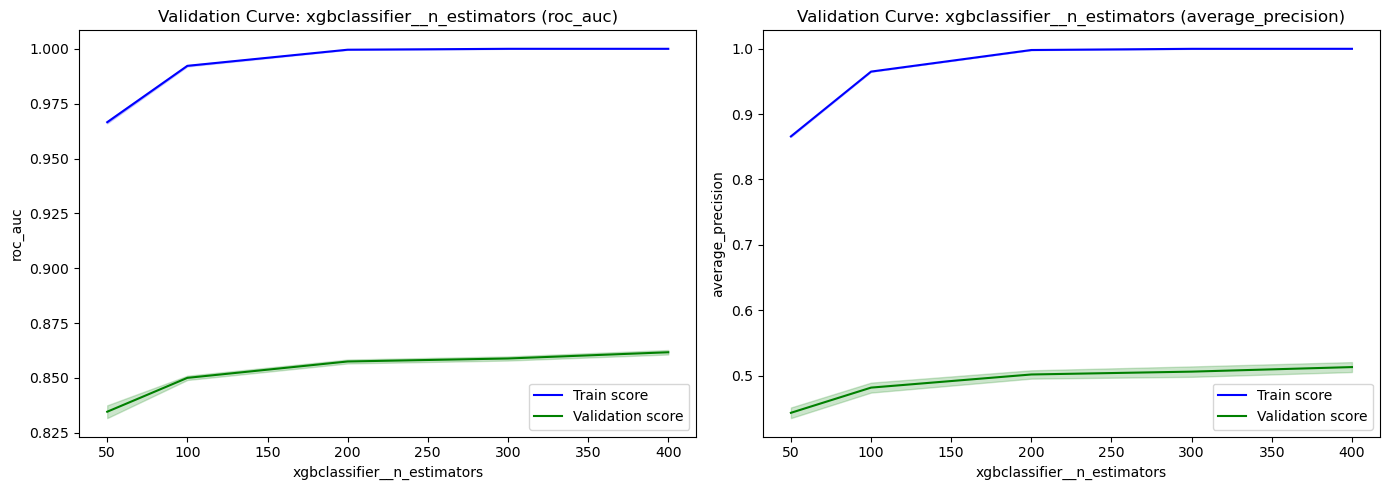

In [9]:
param_name = "xgbclassifier__n_estimators"
param_range = [50, 100, 200, 300, 400]

_plot_validation_curve(param_name, param_range, scorings=("roc_auc", "average_precision"))

[CV] END xgbclassifier__scale_pos_weight=4.475743251648215;, score=(train=0.994, test=0.847) total time=  13.4s
[CV] END xgbclassifier__scale_pos_weight=6.713614877472322;, score=(train=0.993, test=0.843) total time=  13.6s
[CV] END xgbclassifier__scale_pos_weight=8.95148650329643;, score=(train=0.993, test=0.839) total time=  13.3s
[CV] END xgbclassifier__scale_pos_weight=11.189358129120537;, score=(train=0.993, test=0.838) total time=  12.1s
[CV] END xgbclassifier__scale_pos_weight=13.427229754944644;, score=(train=0.992, test=0.833) total time=  13.3s
[CV] END xgbclassifier__scale_pos_weight=4.475743251648215;, score=(train=0.993, test=0.851) total time=  12.8s
[CV] END xgbclassifier__scale_pos_weight=6.713614877472322;, score=(train=0.993, test=0.850) total time=  12.9s
[CV] END xgbclassifier__scale_pos_weight=8.95148650329643;, score=(train=0.993, test=0.845) total time=  12.1s
[CV] END xgbclassifier__scale_pos_weight=11.189358129120537;, score=(train=0.993, test=0.841) total time

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:  3.3min finished


[CV] END xgbclassifier__scale_pos_weight=4.475743251648215;, score=(train=0.959, test=0.475) total time=  13.9s
[CV] END xgbclassifier__scale_pos_weight=6.713614877472322;, score=(train=0.952, test=0.475) total time=  12.8s
[CV] END xgbclassifier__scale_pos_weight=8.95148650329643;, score=(train=0.948, test=0.462) total time=  12.9s
[CV] END xgbclassifier__scale_pos_weight=11.189358129120537;, score=(train=0.944, test=0.467) total time=  14.1s
[CV] END xgbclassifier__scale_pos_weight=13.427229754944644;, score=(train=0.937, test=0.463) total time=  13.4s
[CV] END xgbclassifier__scale_pos_weight=4.475743251648215;, score=(train=0.956, test=0.482) total time=  14.1s
[CV] END xgbclassifier__scale_pos_weight=6.713614877472322;, score=(train=0.949, test=0.477) total time=  14.4s
[CV] END xgbclassifier__scale_pos_weight=8.95148650329643;, score=(train=0.946, test=0.468) total time=  12.4s
[CV] END xgbclassifier__scale_pos_weight=11.189358129120537;, score=(train=0.945, test=0.474) total time

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:  3.4min finished


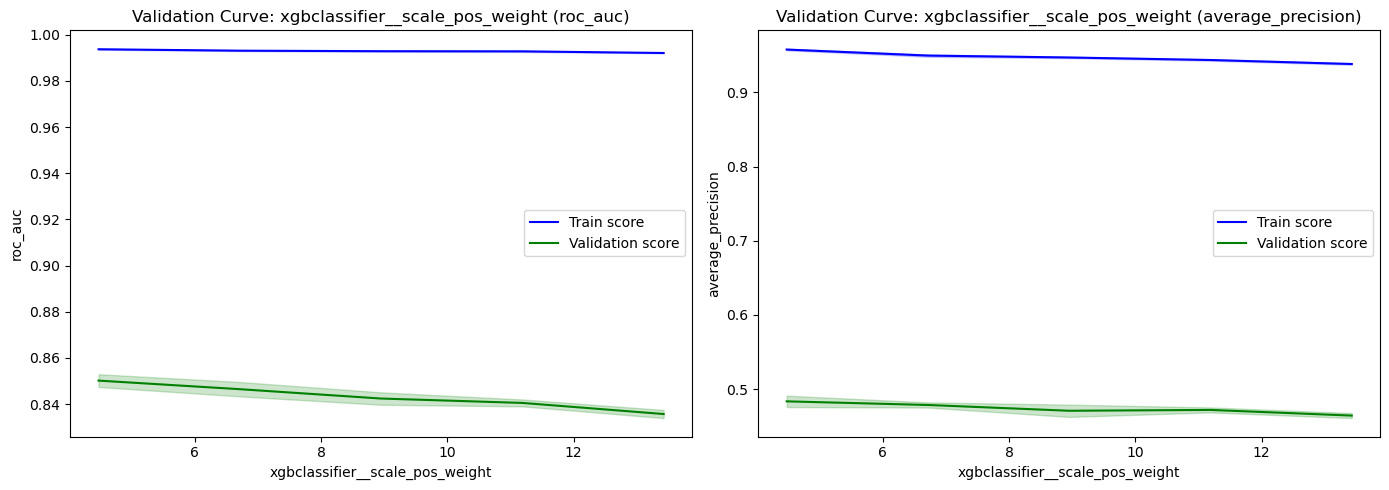

In [17]:
n_pos = np.sum(y_train == True)
n_neg = np.sum(y_train == False)
imbalance_ratio = n_neg / n_pos
param_name = "xgbclassifier__scale_pos_weight"
param_range = np.linspace(0.5 * imbalance_ratio, 1.5 * imbalance_ratio, 5)
_plot_validation_curve(param_name, param_range, scorings=("roc_auc", "average_precision"))

halving search-> feature engineering methods->last training and test and ergebnisse

# Data Compression

In [71]:
pca_pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.99, random_state=42)  # 99% der Varianz behalten
)
X_train_pca = pca_pipeline.fit_transform(df_train)



In [72]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb, X_train_pca, y_train, cv=cv)
print_train_scores(cv_results)
print_test_scores(cv_results)

[CV] END  average_precision: (train=0.914, test=0.481) roc_auc: (train=0.984, test=0.850) total time=  17.1s
[CV] END  average_precision: (train=0.914, test=0.487) roc_auc: (train=0.984, test=0.852) total time=  18.8s
[CV] END  average_precision: (train=0.915, test=0.481) roc_auc: (train=0.984, test=0.850) total time=  15.2s
[CV] END  average_precision: (train=0.919, test=0.482) roc_auc: (train=0.985, test=0.850) total time=  16.1s
mean train_roc_auc                  score = 0.98394 +/- 0.00048
mean train_average_precision        score = 0.91529 +/- 0.00217
mean test_roc_auc                   score = 0.85069 +/- 0.00074
mean test_average_precision         score = 0.48286 +/- 0.00248


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:  1.1min finished


In [74]:
df_train.shape

(160000, 200)

In [73]:
X_train_pca.shape

(160000, 198)

# Feature Engineering

### Clustering

In [6]:
df_train_clusters =  df_train.copy()
p_minibatch = make_pipeline(
    StandardScaler(),
    MiniBatchKMeans(
        n_clusters=500,
        init='k-means++',
        n_init=10,
        random_state=42,
        batch_size=10000   
    )
)
cluster_labels = p_minibatch.fit_predict(df_train_clusters)
df_train_clusters['cluster'] = cluster_labels

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb, df_train_clusters, y_train, cv=cv)
print_train_scores(cv_results)
print_test_scores(cv_results)


KeyboardInterrupt: 

100%|██████████| 5/5 [02:06<00:00, 25.25s/it]


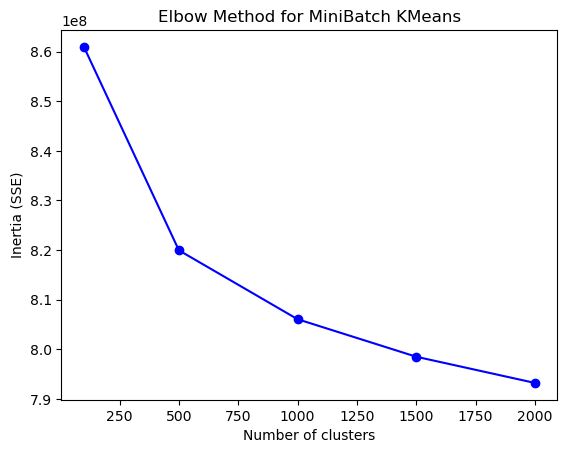

In [40]:
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

inertia = []
K = [100,500,1000,1500,2000]
for k in tqdm(K):
    mbk = MiniBatchKMeans(n_clusters=k, batch_size=10000, random_state=42)
    mbk.fit(df_train)
    inertia.append(mbk.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method for MiniBatch KMeans')
plt.show()


In [ ]:
p_xgb.fit(df_train_clusters, y_train)
xgb_model = p_xgb.named_steps['xgbclassifier']

importances = xgb_model.get_booster().get_score(importance_type='gain')
importances

[860954443.7125098,
 819954919.0872692,
 806066473.7364048,
 798504460.47573,
 793221678.1607738]

## Row Level Stats

In [7]:
df_row_stats = df_train.copy()
df_row_stats['row_mean'] = df_row_stats.mean(axis=1)
df_row_stats['row_std'] = df_row_stats.std(axis=1)
df_row_stats['row_min'] = df_row_stats.min(axis=1)
df_row_stats['row_max'] = df_row_stats.max(axis=1)
df_row_stats['row_median'] = df_row_stats.median(axis=1)
df_row_stats['row_sum'] = df_row_stats.sum(axis=1)
df_row_stats['row_kurtosis'] = df_row_stats.kurtosis(axis=1)
df_row_stats['row_skew'] = df_row_stats.skew(axis=1)
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb, df_row_stats, y_train, cv=cv)
print_train_scores(cv_results)
print_test_scores(cv_results)

[CV] END  average_precision: (train=0.953, test=0.484) roc_auc: (train=0.990, test=0.850) total time=  17.8s
[CV] END  average_precision: (train=0.954, test=0.485) roc_auc: (train=0.990, test=0.853) total time=  17.4s
[CV] END  average_precision: (train=0.954, test=0.487) roc_auc: (train=0.990, test=0.855) total time=  32.7s
[CV] END  average_precision: (train=0.955, test=0.488) roc_auc: (train=0.990, test=0.854) total time=  34.4s
mean train_roc_auc                  score = 0.98967 +/- 0.00014
mean train_average_precision        score = 0.95389 +/- 0.00043
mean test_roc_auc                   score = 0.85311 +/- 0.00198
mean test_average_precision         score = 0.48606 +/- 0.00162


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:  1.7min finished


## PCA

In [8]:
df_pca = df_train.copy()

# Pipeline: StandardScaler -> PCA
pca_pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.99, random_state=42)  # 99% der Varianz behalten
)

# PCA auf den Trainingsdaten fitten und transformieren
X_pca = pca_pipeline.fit_transform(df_pca)

# PCA-Komponenten direkt zum existierenden DataFrame hinzufügen
for i in range(X_pca.shape[1]):
    df_pca[f'pca_{i+1}'] = X_pca[:, i]

# Cross-Validation mit XGBoost auf erweitertem Datensatz
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb, df_pca, y_train, cv=cv)

# Ergebnisse ausgeben
print_train_scores(cv_results)
print_test_scores(cv_results)

C:\Users\marou\AppData\Local\Temp\ipykernel_19328\3509314784.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pca[f'pca_{i+1}'] = X_pca[:, i]
C:\Users\marou\AppData\Local\Temp\ipykernel_19328\3509314784.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pca[f'pca_{i+1}'] = X_pca[:, i]
C:\Users\marou\AppData\Local\Temp\ipykernel_19328\3509314784.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all 

[CV] END  average_precision: (train=0.943, test=0.536) roc_auc: (train=0.988, test=0.873) total time= 1.4min
[CV] END  average_precision: (train=0.943, test=0.539) roc_auc: (train=0.988, test=0.874) total time= 1.2min
[CV] END  average_precision: (train=0.944, test=0.531) roc_auc: (train=0.988, test=0.872) total time= 1.2min
[CV] END  average_precision: (train=0.945, test=0.533) roc_auc: (train=0.988, test=0.871) total time= 1.3min
mean train_roc_auc                  score = 0.98803 +/- 0.00007
mean train_average_precision        score = 0.94376 +/- 0.00067
mean test_roc_auc                   score = 0.87240 +/- 0.00115
mean test_average_precision         score = 0.53456 +/- 0.00293


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:  5.2min finished


In [31]:
df_train_flagged = df_train.copy()
def flag_duplicates(df, features, new_col_suffix='_FE'):
    df = df.copy()
    new_cols = {}
    
    for col in features:
        counts = df[col].value_counts()
        new_col = col + new_col_suffix
        new_cols[new_col] = df[col].map(counts).astype('uint32')  # choose appropriate dtype

    # Add all new columns at once
    df = pd.concat([df, pd.DataFrame(new_cols)], axis=1)
    return df
df_train_flagged = flag_duplicates(df_train_flagged, df_train_flagged.columns.tolist())
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb, df_train_flagged, y_train, cv=cv)

# Ergebnisse ausgeben
print_train_scores(cv_results)
print_test_scores(cv_results)

[CV] END  average_precision: (train=0.959, test=0.496) roc_auc: (train=0.991, test=0.856) total time=  30.6s
[CV] END  average_precision: (train=0.957, test=0.498) roc_auc: (train=0.990, test=0.857) total time=  32.2s
[CV] END  average_precision: (train=0.957, test=0.490) roc_auc: (train=0.990, test=0.857) total time=  36.1s
[CV] END  average_precision: (train=0.958, test=0.492) roc_auc: (train=0.990, test=0.857) total time=  34.6s
mean train_roc_auc                  score = 0.99049 +/- 0.00025
mean train_average_precision        score = 0.95802 +/- 0.00082
mean test_roc_auc                   score = 0.85664 +/- 0.00045
mean test_average_precision         score = 0.49398 +/- 0.00311


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:  2.3min finished


# new counting 

In [4]:
df_train_flagged_unique = df_train.copy()
def flag_unique_values(df, features=None, suffix='_unique'):
    """
    For each feature in the dataframe, create a new column indicating
    whether the value is unique in that column (1) or not (0).
    """
    df = df.copy()
    if features is None:
        features = df.columns.tolist()
    
    for feature in tqdm(features, desc="Flagging unique values"):
        values = df[feature].values
        _, indices, counts = np.unique(values, return_index=True, return_counts=True)
        # Initialize column with zeros
        unique_flag = np.zeros(df.shape[0], dtype=int)
        # Mark values that appear only once as 1
        unique_flag[indices[counts == 1]] = 1
        df[feature + suffix] = unique_flag
    
    return df
#df_train_flagged_unique = flag_unique_values(df_train_flagged_unique, df_train_flagged_unique.columns.tolist())
#cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
#cv_results = run_cv(p_xgb, df_train_flagged_unique, y_train, cv=cv)
#print_train_scores(cv_results)
#print_test_scores(cv_results)

# HyperparameterTuning

In [51]:
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedKFold
import xgboost as xgb

# Base model
xgb_model = xgb.XGBClassifier(
    n_jobs=-1,
    random_state=42
)

# Parameter distributions
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],          # row sampling
    'colsample_bytree': [0.6, 0.8, 1.0],   # column sampling
    'reg_alpha': [0, 0.01, 0.1],           # L1 regularization
    'reg_lambda': [1, 1.5, 2],             # L2 regularization
    'min_child_weight': [1, 5, 10],        # minimum sum of instance weight per child
    'gamma': [0, 0.1, 0.5]                 # minimum loss reduction to make a split
}

# Stratified CV
cv_strategy = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# Halving search with n_estimators as resource
halving_search = HalvingRandomSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    factor=3,                     # reduce candidates by ~1/3 each round
    resource='n_estimators',      # grow number of trees instead of samples
    min_resources=50,             # start with 50 trees
    max_resources=500,            # allow up to 500 trees
    scoring='average_precision',  # PR-AUC is good for imbalance
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=3
)

# Fit
halving_search.fit(df_pca, y_train)

# Results
print("Best params:", halving_search.best_params_)
print("Best Average Precision:", halving_search.best_score_)

best_model = halving_search.best_estimator_


n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 50
max_resources_: 500
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 10
n_resources: 50
Fitting 4 folds for each of 10 candidates, totalling 40 fits
----------
iter: 1
n_candidates: 4
n_resources: 150
Fitting 4 folds for each of 4 candidates, totalling 16 fits
----------
iter: 2
n_candidates: 2
n_resources: 450
Fitting 4 folds for each of 2 candidates, totalling 8 fits
Best params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.01, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0, 'n_estimators': 450}
Best Average Precision: 0.582690860128941


66 min for training halvingsearch

In [13]:
best_pars_pca= {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.01, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0, 'n_estimators': 450}
p_xgb_final = make_pipeline(
    xgb.XGBClassifier(
        random_state=42,
        **best_pars_pca
    )
)
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb_final, df_pca, y_train, cv=cv)
print_train_scores(cv_results)
print_test_scores(cv_results)

[CV] END  average_precision: (train=0.897, test=0.582) roc_auc: (train=0.979, test=0.887) total time= 3.1min
[CV] END  average_precision: (train=0.893, test=0.580) roc_auc: (train=0.977, test=0.890) total time= 3.5min
[CV] END  average_precision: (train=0.899, test=0.583) roc_auc: (train=0.979, test=0.888) total time= 3.5min
[CV] END  average_precision: (train=0.896, test=0.582) roc_auc: (train=0.978, test=0.886) total time= 3.0min
mean train_roc_auc                  score = 0.97813 +/- 0.00053
mean train_average_precision        score = 0.89613 +/- 0.00236
mean test_roc_auc                   score = 0.88807 +/- 0.00130
mean test_average_precision         score = 0.58172 +/- 0.00106


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed: 13.1min finished


In [18]:
best_pars_pca= {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.01, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0, 'n_estimators': 450}
p_xgb_final = make_pipeline(
    xgb.XGBClassifier(
        random_state=42,
        **best_pars_pca
    )
)
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb_final, df_train, y_train, cv=cv)
print_train_scores(cv_results)
print_test_scores(cv_results)

[CV] END  average_precision: (train=0.915, test=0.575) roc_auc: (train=0.981, test=0.883) total time=  39.6s
[CV] END  average_precision: (train=0.916, test=0.579) roc_auc: (train=0.981, test=0.888) total time=  39.7s
[CV] END  average_precision: (train=0.914, test=0.576) roc_auc: (train=0.981, test=0.886) total time=  41.1s
[CV] END  average_precision: (train=0.914, test=0.580) roc_auc: (train=0.981, test=0.886) total time=  42.1s
mean train_roc_auc                  score = 0.98118 +/- 0.00013
mean train_average_precision        score = 0.91469 +/- 0.00067
mean test_roc_auc                   score = 0.88578 +/- 0.00190
mean test_average_precision         score = 0.57737 +/- 0.00211


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:  2.7min finished


In [32]:
best_pars_pca= {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.01, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0, 'n_estimators': 450}
p_xgb_final = make_pipeline(
    xgb.XGBClassifier(
        random_state=42,
        **best_pars_pca
    )
)
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb_final, df_train_flagged, y_train, cv=cv)
print_train_scores(cv_results)
print_test_scores(cv_results)

[CV] END  average_precision: (train=0.924, test=0.589) roc_auc: (train=0.983, test=0.888) total time= 2.1min
[CV] END  average_precision: (train=0.924, test=0.587) roc_auc: (train=0.983, test=0.890) total time= 1.8min
[CV] END  average_precision: (train=0.926, test=0.590) roc_auc: (train=0.984, test=0.891) total time= 2.0min
[CV] END  average_precision: (train=0.924, test=0.589) roc_auc: (train=0.984, test=0.888) total time= 2.0min
mean train_roc_auc                  score = 0.98357 +/- 0.00020
mean train_average_precision        score = 0.92448 +/- 0.00073
mean test_roc_auc                   score = 0.88927 +/- 0.00136
mean test_average_precision         score = 0.58872 +/- 0.00114


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:  8.0min finished


In [62]:
best_pars_pca= {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.01, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0, 'n_estimators': 450}
p_xgb_final = make_pipeline(
    xgb.XGBClassifier(
        random_state=42,
        **best_pars_pca
    )
)
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
cv_results = run_cv(p_xgb_final, df_train_flagged_unique, y_train, cv=cv)
print_train_scores(cv_results)
print_test_scores(cv_results)

[CV] END  average_precision: (train=0.922, test=0.588) roc_auc: (train=0.983, test=0.888) total time= 2.5min
[CV] END  average_precision: (train=0.920, test=0.590) roc_auc: (train=0.982, test=0.892) total time= 2.3min
[CV] END  average_precision: (train=0.921, test=0.586) roc_auc: (train=0.983, test=0.890) total time= 2.3min
[CV] END  average_precision: (train=0.920, test=0.593) roc_auc: (train=0.982, test=0.889) total time= 1.8min
mean train_roc_auc                  score = 0.98233 +/- 0.00035
mean train_average_precision        score = 0.92060 +/- 0.00085
mean test_roc_auc                   score = 0.88991 +/- 0.00154
mean test_average_precision         score = 0.58924 +/- 0.00254


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:  8.9min finished


## Final with nunique 

In [63]:
from sklearn.metrics import average_precision_score, roc_auc_score

df_test_flagged_unique = flag_unique_values(df_test, df_test.columns.tolist())
p_xgb_final.fit(df_train_flagged_unique, y_train)

# Predictions on test set
y_proba = p_xgb_final.predict_proba(df_test_flagged_unique)[:, 1]

# Metrics
ap = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Average Precision (AP): {ap:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


Flagging unique values:  47%|████▋     | 94/200 [00:00<00:00, 116.82it/s]C:\Users\marou\AppData\Local\Temp\ipykernel_19328\2748134068.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[feature + suffix] = unique_flag
C:\Users\marou\AppData\Local\Temp\ipykernel_19328\2748134068.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[feature + suffix] = unique_flag
C:\Users\marou\AppData\Local\Temp\ipykernel_19328\2748134068.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fra

Average Precision (AP): 0.5759
ROC-AUC: 0.8883


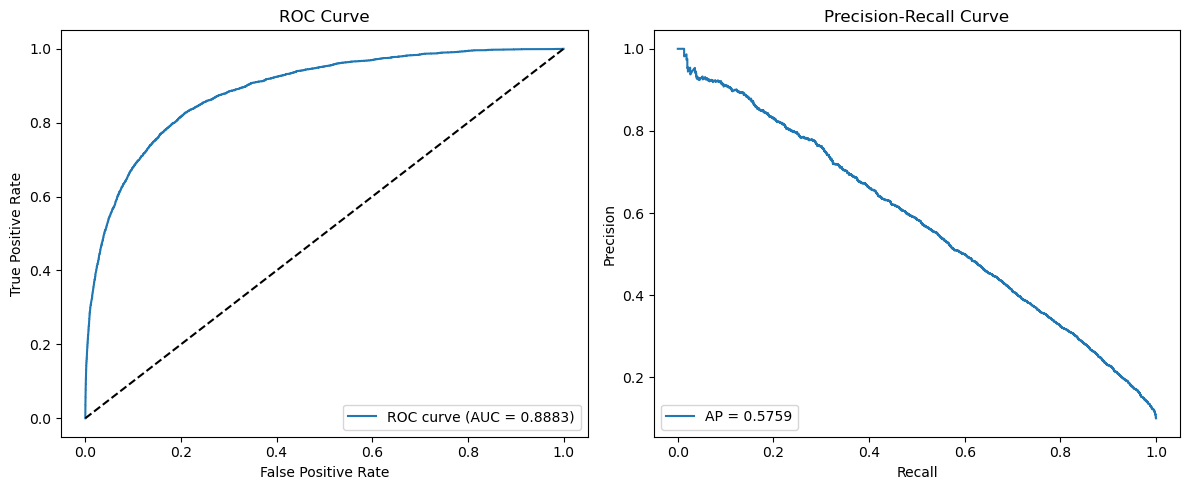

In [64]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)

# Plot ROC Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line (random classifier)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [7]:
lr_pipeline_pca = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)


lr_pipeline_pca.fit(df_train, y_train)

# Predictions on test set
y_proba = lr_pipeline_pca.predict_proba(df_test)[:, 1]

# Metrics
ap = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Average Precision (AP): {ap:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Average Precision (AP): 0.5004
ROC-AUC: 0.8599


In [6]:
from sklearn.metrics import average_precision_score, roc_auc_score
p_xgb_final = make_pipeline(
    xgb.XGBClassifier(
        random_state=42,
        #**best_pars_pca
    )
)

#df_test_flagged_unique = flag_unique_values(df_test, df_test.columns.tolist())
p_xgb_final.fit(df_train, y_train)

# Predictions on test set
y_proba = p_xgb_final.predict_proba(df_test)[:, 1]

# Metrics
ap = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Average Precision (AP): {ap:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Average Precision (AP): 0.4889
ROC-AUC: 0.8597


In [ ]:
Average Precision (AP): 0.5004 ROC-AUC: 0.8599

1
